<a href="https://colab.research.google.com/github/Pameta1/TelecomX_2/blob/main/TelecomX_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1148]:
import pandas as pd

In [1149]:
datos_cliente = pd.read_csv('/content/datos_tratados.csv')

In [1150]:
import warnings
warnings.filterwarnings('ignore')

In [1151]:
datos_cliente.head(2)

,CustomerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn_bin,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3,0.0,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4,0.0,1.996667


#### Eliminación de Columnas

In [1152]:
columnas_a_eliminar = ['CustomerID', 'Churn']

In [1153]:
datos_cliente = datos_cliente.drop(columns=['CustomerID', 'Churn'])

In [1154]:
datos_cliente.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn_bin,Cuentas_Diarias
0,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,...,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3,0.0,2.186667
1,Male,0,No,No,9,Yes,Yes,DSL,No,No,...,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4,0.0,1.996667


##### Gestión de limpieza de datos numéricos

In [1155]:
cols_num = ['MonthlyCharges', 'TotalCharges', 'Cuentas_Diarias', 'Churn_bin']

for col in cols_num:
    datos_cliente[col] = (
        datos_cliente[col]
        .astype(str)      # asegurar que es string
        .str.strip()      # eliminar espacios
        .replace('', None)  # convertir vacío en NaN real
    )

In [1156]:
for col in cols_num:
    datos_cliente[col] = pd.to_numeric(datos_cliente[col], errors='coerce')

In [1157]:
for col in cols_num:
    try:
        datos_cliente[col].astype(float)
        print(f"{col} OK")
    except:
        print(f"{col} tiene problema")

MonthlyCharges OK
TotalCharges OK
Cuentas_Diarias OK
Churn_bin OK


In [1158]:
datos_cliente_corr = datos_cliente[cols_num].dropna()
datos_cliente_corr.corr()

,MonthlyCharges,TotalCharges,Cuentas_Diarias,Churn_bin
MonthlyCharges,1.000000,0.651065,1.000000,0.192858
TotalCharges,0.651065,1.000000,0.651065,-0.199484
Cuentas_Diarias,1.000000,0.651065,1.000000,0.192858
Churn_bin,0.192858,-0.199484,0.192858,1.000000


In [1159]:
datos_cliente['Churn_bin'].isna().sum()

np.int64(224)

In [1160]:
datos_cliente = datos_cliente.dropna(subset=['Churn_bin'])

In [1161]:
# Separar X e y
X = datos_cliente.drop('Churn_bin', axis=1)
y = datos_cliente['Churn_bin']

In [1162]:
# Separar variables predictoras y objetivo
X = datos_cliente.drop('Churn_bin', axis=1)
y = datos_cliente['Churn_bin']

Se identificaron 11 valores faltantes en la variable TotalCharges, asociados a clientes con antigüedad (tenure) igual a cero. Debido a que representan una proporción mínima del dataset, estos registros fueron eliminados para evitar inconsistencias durante el entrenamiento de los modelos.

In [1163]:
datos_cliente = datos_cliente.dropna(subset=['TotalCharges'])

In [1164]:
X = datos_cliente.drop('Churn_bin', axis=1)
y = datos_cliente['Churn_bin']

In [1165]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [1166]:
print("NaN en X:", X_encoded.isna().sum().sum())
print("NaN en y:", y.isna().sum())

NaN en X: 0
NaN en y: 0


In [1167]:
# Dividir train-test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=42, stratify=y)

In [1168]:
 # Pipeline de preprocesamiento
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Identificar columnas
columnas_numericas = X.select_dtypes(include=['int64','float64']).columns
columnas_categoricas = X.select_dtypes(include=['object']).columns

preprocesador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), columnas_numericas),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), columnas_categoricas)
    ]
)

In [1169]:
# Aplicar One_Hot Encoding
X_encoded = pd.get_dummies(X,drop_first=True)

print(X_encoded.shape)

(7032, 31)


In [1170]:
X.select_dtypes(include=['object']).columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [1171]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline_log = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('modelo', LogisticRegression(max_iter=1000))
])

pipeline_log.fit(X_train, y_train)

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'Cuentas_Diarias'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('modelo', LogisticRegression(max_iter=1000))])

## Verificación de la proporción de cancelación (Churn)

Primeo calculamos cuántos clientes cancelaron y los que  no cancelaron

In [1172]:
datos_cliente['Churn_bin'].value_counts()

,count
Churn_bin,
0.0,5163
1.0,1869




*   0 = cliente activo
*   1 = cliente canceló



####Proporción (porcentaje)

In [1173]:
(datos_cliente['Churn_bin'].value_counts(normalize=True) * 100).round(2)

,proportion
Churn_bin,
0.0,73.42
1.0,26.58


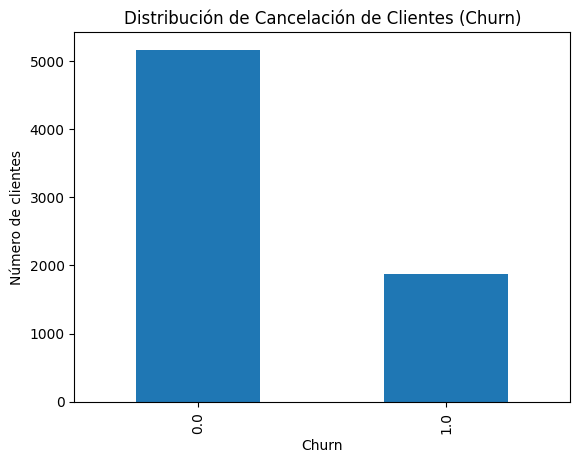

In [1174]:
import matplotlib.pyplot as plt

datos_cliente['Churn_bin'].value_counts().plot(
    kind='bar',
    title='Distribución de Cancelación de Clientes (Churn)',
)

plt.xlabel('Churn')
plt.ylabel('Número de clientes')
plt.show()

##Interpretación

El análisis de la variable objetivo muestra que aproximadamente 73% de los clientes permanecen activos, mientras que cerca del 27% han cancelado el servicio.
Esto indica un desbalance moderado entre las clases, lo cual es común en problemas de churn y debe considerarse al evaluar el desempeño de los modelos predictivos.

####Balanceo de Clases Técnica SMOTE

In [1175]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_bal, y_bal = smote.fit_resample(X_encoded, y)

In [1176]:
y_bal.value_counts()

,count
Churn_bin,
0.0,5163
1.0,5163


Debido al desbalance existente entre clientes que cancelan y aquellos que permanecen activos, se aplicó la técnica SMOTE (Synthetic Minority Over-sampling Technique) para generar ejemplos sintéticos de la clase minoritaria. Esto permite entrenar modelos más equilibrados y mejorar la capacidad de detectar clientes con riesgo de cancelación.

####Evaluar la necesidad de normalización /estandarización

##Aplicar estandireación con StandarScaler

In [1177]:
# Identificación de variables numéricas
from sklearn.preprocessing import StandardScaler

columnas_numericas = ['tenure','MonthlyCharges','TotalCharges','Cuentas_Diarias']

In [1178]:
scaler = StandardScaler()

X_encoded[columnas_numericas] = scaler.fit_transform(X_encoded[columnas_numericas])

In [1179]:
X_encoded[columnas_numericas].describe()

,tenure,MonthlyCharges,TotalCharges,Cuentas_Diarias
count,7.032000e+03,7.032000e+03,7.032000e+03,7.032000e+03
mean,-1.111486e-16,5.860563e-17,8.285623e-17,7.729880e-17
std,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00
min,-1.280248e+00,-1.547283e+00,-9.990692e-01,-1.547283e+00
25%,-9.542963e-01,-9.709769e-01,-8.302488e-01,-9.709769e-01
50%,-1.394171e-01,1.845440e-01,-3.908151e-01,1.845440e-01
75%,9.199259e-01,8.331482e-01,6.668271e-01,8.331482e-01
max,1.612573e+00,1.793381e+00,2.824261e+00,1.793381e+00


Se aplicó estandarización mediante StandardScaler a las variables numéricas para garantizar que todas tengan media cero y desviación estándar uno. Este paso es necesario para modelos sensibles a la escala de los datos, como Regresión Logística, evitando que variables con magnitudes mayores influyan desproporcionadamente en el modelo.

###Correlación y Selección de Variables

In [1180]:
# Seleccionar solo variables numéricas

variables_numericas = datos_cliente.select_dtypes(include=['int64','float64'])

variables_numericas.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn_bin,Cuentas_Diarias
0,0,9,65.6,593.30,0.0,2.186667
1,0,9,59.9,542.40,0.0,1.996667
2,0,4,73.9,280.85,1.0,2.463333
3,1,13,98.0,1237.85,1.0,3.266667
4,1,3,83.9,267.40,1.0,2.796667


###Calcular matriz de correlación